# Model 1 Fig. 1b notebook

This notebook is split into modules so you can edit parameters, energy update rules, run simulations, plot, and diagnose results separately.

## 1. Imports

In [49]:
from __future__ import annotations

from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, Tuple

import numpy as np
import matplotlib.pyplot as plt

try:
    from numba import njit
    NUMBA_AVAILABLE = True
except Exception:  # pragma: no cover
    NUMBA_AVAILABLE = False
    def njit(*args, **kwargs):
        def deco(func):
            return func
        return deco

## 2. Digitized paper data

In [50]:
# -----------------------------------------------------------------------------
# Digitized Fig. 1b data supplied by the user
# -----------------------------------------------------------------------------

initial_maxwell = np.array([
    [1.1161376360074342, 0.05212605070666866],
    [1.559848645008699, 0.04284095812550353],
    [2.0545603400190444, 0.03863629825343095],
    [2.7174171982263053, 0.03304021906072346],
    [3.6824963769086585, 0.027336921663521606],
    [4.872012442209523, 0.024315287153814168],
    [6.798762797939492, 0.01916821802892673],
    [9.306571177937665, 0.015807268522315152],
    [11.765222107359008, 0.014370853490838782],
    [16.213006727523894, 0.011570454936627898],
    [22.43130108974015, 0.009082898160931375],
    [29.458083712470284, 0.007496205282732272],
    [39.49657279085176, 0.005733970886294479],
    [52.95589752033582, 0.004185893292613626],
    [68.90398164690043, 0.0032601487541149745],
    [95.19719984355861, 0.0020517178225330918],
    [128.6626258726999, 0.0012202941192593524],
    [166.63118972253983, 0.0007876170063120585],
    [225.20837227592756, 0.0003550276265398501],
    [286.1663842072925, 0.000159566469700413],
    [365.8466111926846, 0.00006580457677300633],
    [418.0109291290068, 0.00003148377825892911],
    [484.0219946576641, 0.000015457502750512802],
    [575.5993268589666, 0.000005273616905038984],
    [648.9631209879724, 0.0000022972104541256495],
    [702.9965241637434, 0.0000012360009167581451],
    [761.5288095784782, 6.840255859682924e-7],
    [814.0116828336006, 3.857295679051362e-7],
    [893.6195433342089, 1.6293446851332446e-7],
    [981.0128098518692, 6.564346957602644e-8],
    [1034.7373326600416, 3.038342770231927e-8],
    [1106.0491301905904, 1.4146390581761444e-8],
    [1182.2755783348991, 6.768340764708475e-9],
    [1247.0221245939545, 3.299710335947106e-9],
    [1405.9630235040768, 6.852163942655141e-10],
    [1315.3144729733383, 1.760447842207669e-9],
    [1502.8588706944106, 2.484578835667482e-10],
    [1578.1345183254646, 9.130258647124002e-11],
    [1627.988599411337, 4.187611022171262e-11],
    [1717.1443268005924, 1.7337791428579943e-11],
    [1811.1826090978952, 7.1379599198553865e-12],
    [1910.3708362189454, 3.077082635950235e-12],
    [2182.7614737922354, 1.4298169854756678e-13],
], dtype=float)

stable = np.array([
    [1.107082832045625, 0.000026524911644687507],
    [1.9113068445030679, 0.000058928816956753016],
    [2.5467356489724597, 0.000051426770770898046],
    [3.399453993927438, 0.00004602445162065894],
    [4.492932889875057, 0.00003609612747318974],
    [6.159198784617767, 0.000022830617708267264],
    [7.624547696204331, 0.000014569501343604905],
    [10.141348100155756, 0.00001600289165104321],
    [13.749112344399936, 0.000016162639219874276],
    [18.069506478760584, 0.00001679446660370579],
    [24.59897729636845, 0.00001720881368564048],
    [33.59860486001964, 0.000015399546319902216],
    [41.738980083930194, 0.000012661083947886116],
    [54.38661797436929, 0.00000783100980630772],
    [72.9200526632895, 0.000007267332565782592],
    [97.76916231347204, 0.000009340768697177838],
    [131.08615189317177, 0.000008598397746523724],
    [175.75663748723647, 0.000007629729798405962],
    [235.64957224462512, 0.000006704044416600939],
    [315.95234008221996, 0.000008463660030176857],
    [422.3671016655875, 0.000009879389695336369],
    [567.9778734426466, 0.000009316875575244112],
    [761.5288095784782, 0.00000839529297113774],
    [1021.0364785919337, 0.0000073108934312350975],
    [1368.9770859653622, 0.0000052270449524074064],
    [1835.486097894074, 0.000003743549369102293],
    [2333.1925439425713, 0.000003571831720406896],
    [3445.678361798389, 0.0000023352758346130597],
    [5054.805639039484, 0.000001862045792745237],
    [6777.341690471725, 0.0000014661338180653758],
    [9086.86973731677, 0.0000011108924913122574],
    [12183.420195421248, 8.791843119392594e-7],
    [16335.188238543986, 7.011723720784066e-7],
    [21901.762436868794, 5.47861879126108e-7],
    [29365.269064312488, 3.83431255945508e-7],
    [39372.12951263974, 3.105319648698184e-7],
    [52789.047461648835, 2.401614568835712e-7],
    [70778.07490736809, 1.6894462662570155e-7],
    [94897.25858820295, 1.3021418142959912e-7],
    [127235.58389151351, 9.551405640693812e-8],
    [170593.90386043084, 6.169229892597364e-8],
    [228727.5237338937, 4.529087725799175e-8],
    [306671.4514971225, 3.124093351219156e-8],
    [411176.48470137175, 2.0684266083465912e-8],
    [551293.9034462544, 1.4587924673251808e-8],
    [739159.4103387052, 8.710557666651602e-9],
    [991044.215212381, 5.455841658846654e-9],
    [1328764.3000524945, 3.724995378546707e-9],
    [1781569.9218986146, 2.114961738297441e-9],
    [2205081.43223623, 1.6223332972279804e-9],
    [2878735.959574978, 9.708138065907702e-10],
    [4410068.685940515, 4.603625487769857e-10],
    [5458422.06624728, 2.9587833135602114e-10],
    [7221595.759969815, 1.7009231832069338e-10],
    [10077543.351341229, 9.192830941150034e-11],
    [11327094.51929014, 4.9660040384045725e-11],
    [17639521.339640364, 1.4615102927409118e-11],
    [27022798.12644323, 5.448147075249954e-12],
    [40308451.78530921, 4.427734958851969e-12],
    [47300141.27349298, 2.1738726763388236e-12],
    [64269691.96722608, 1.3753286714090985e-12],
], dtype=float)

## 3. Configuration class and constants

In [51]:
# -----------------------------------------------------------------------------
# Parameters and constants
# -----------------------------------------------------------------------------

@dataclass
class Model1Config:
    B: float = 100.0
    N: int = 601
    L: float = 1.0e10
    active_ratio: float = 0.1
    Vfactor: float = 1.0
    n0: float = 1.0e9

    n_particles: int = 300_000
    kT0_eV: float = 100.0
    ion: bool = False
    Zion: int = 1
    start_center: bool = False
    monoenergetic: bool = False
    v0_threshold_factor: float = 0.0

    iBCs: int = 0
    tinit: float = 0.0
    tfin: float = 20.0
    target_time: float = 20.0
    stop_at_tfin: bool = True

    seed: int = 1
    n_bins: int = 80
    output: str = "fig1b_gaussian_vs_maxwell_N0norm.png"
    npz_output: str = "fig1b_gaussian_vs_maxwell_N0norm_results.npz"

    def normalized(self) -> "Model1Config":
        self.N = int(self.N + 1 - (self.N % 2))
        return self


ME = 9.10938e-28
MP = 1.67262e-24
C = 2.99792458e10
ERG2EV = 6.2415e11
C2 = C * C

## 4. Derived physical quantities

In [52]:
def derived_quantities(cfg: Model1Config) -> Dict[str, float]:
    m = cfg.Zion * MP if cfg.ion else ME
    VA = cfg.B / np.sqrt(4.0 * np.pi * cfg.n0 * MP)
    V = cfg.Vfactor * VA
    l = cfg.L / (cfg.N - 1)
    Wrest = m * C2
    vth = np.sqrt(2.0 * (cfg.kT0_eV / ERG2EV) / m)
    mfp0 = l / cfg.active_ratio
    alpha0 = (4.0 / 3.0) * V * V / (C * mfp0)
    tacc0 = 1.0 / alpha0
    return dict(m=m, VA=VA, V=V, l=l, Wrest=Wrest, vth=vth,
                mfp0=mfp0, alpha0=alpha0, tacc0=tacc0)

## 5. Initial energy distributions

In [ ]:
def initial_energy_distribution(
    cfg: Model1Config,
    rng: np.random.Generator,
    init_mode: str,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Return (W0_erg, v0_cm_s).

    init_mode="gaussian_abs":v=|N(0,sigma^2)|.
    init_mode="maxwell3d": true 3D Maxwell-Boltzmann speed, v=sqrt(vx^2+vy^2+vz^2).
    """
    dq = derived_quantities(cfg)
    m = dq["m"]
    Wrest = dq["Wrest"]
    vth = dq["vth"]
    gamma_lim = 1.00001

    if cfg.monoenergetic:
        W0 = np.full(cfg.n_particles, cfg.kT0_eV / ERG2EV)
        gamma = 1.0 + W0[0] / Wrest
        v0_const = C * np.sqrt(1.0 - 1.0 / gamma**2) if gamma > gamma_lim else np.sqrt(2.0 * W0[0] / m)
        v0 = np.full(cfg.n_particles, v0_const)
        return W0, v0

    sigma2 = (cfg.kT0_eV / ERG2EV) / m
    sigma = np.sqrt(sigma2)

    if init_mode == "gaussian_abs":
        v0 = np.abs(rng.normal(0.0, sigma, size=cfg.n_particles))
    elif init_mode == "maxwell3d":
        vel = rng.normal(0.0, sigma, size=(cfg.n_particles, 3))
        v0 = np.sqrt(np.sum(vel * vel, axis=1))
    else:
        raise ValueError(f"Unknown init_mode={init_mode!r}")

    if cfg.v0_threshold_factor > 0:
        threshold = cfg.v0_threshold_factor * vth
        bad = v0 < threshold
        while np.any(bad):
            nbad = np.count_nonzero(bad)
            if init_mode == "gaussian_abs":
                v0[bad] = np.abs(rng.normal(0.0, sigma, size=nbad))
            else:
                vel = rng.normal(0.0, sigma, size=(nbad, 3))
                v0[bad] = np.sqrt(np.sum(vel * vel, axis=1))
            bad = v0 < threshold

    gamma = 1.0 / np.sqrt(1.0 - (v0 / C)**2)
    W0 = np.where(gamma > gamma_lim, (gamma - 1.0) * Wrest, 0.5 * m * v0 * v0)
    return W0, v0

## 6. Numba helper functions

In [54]:
@njit
def _hash_active(i: int, j: int, k: int, seed: int, active_ratio: float) -> bool:
    x = np.uint64(i) * np.uint64(0x9E3779B185EBCA87)
    x ^= np.uint64(j) * np.uint64(0xC2B2AE3D27D4EB4F)
    x ^= np.uint64(k) * np.uint64(0x165667B19E3779F9)
    x ^= np.uint64(seed) * np.uint64(0x85EBCA77C2B2AE63)
    x ^= x >> np.uint64(33)
    x *= np.uint64(0xff51afd7ed558ccd)
    x ^= x >> np.uint64(33)
    x *= np.uint64(0xc4ceb9fe1a85ec53)
    x ^= x >> np.uint64(33)
    u = (x >> np.uint64(11)) * (1.0 / 9007199254740992.0)
    return u < active_ratio


@njit
def _draw_lattice_dir(ndims: int) -> np.ndarray:
    pdir = np.zeros(3, dtype=np.int64)
    coin = np.random.randint(0, 2 * ndims)
    axis = coin % ndims
    sign = -1 if coin < ndims else 1
    pdir[axis] = sign
    return pdir


@njit
def _energy_from_v(v: float, m: float, Wrest: float, gamma_lim: float) -> float:
    gamma = 1.0 / np.sqrt(1.0 - (v / C) ** 2)
    if gamma > gamma_lim:
        return (gamma - 1.0) * Wrest
    return 0.5 * m * v * v


@njit
def _v_from_energy(W: float, m: float, Wrest: float, gamma_lim: float) -> float:
    gamma = 1.0 + W / Wrest
    if gamma > gamma_lim:
        return C * np.sqrt(1.0 - 1.0 / (gamma * gamma))
    return np.sqrt(2.0 * W / m)

## 7. Core simulation kernel

To test a different energy update rule, edit the `dW = ...` lines in this cell, then re-run this cell and the later run/plot cells.

In [55]:
@njit
def _simulate_core(
    W0: np.ndarray,
    v0: np.ndarray,
    N: int,
    L: float,
    active_ratio: float,
    V: float,
    m: float,
    Wrest: float,
    kT0_eV: float,
    iBCs: int,
    tfin: float,
    target_time: float,
    stop_at_tfin: bool,
    start_center: bool,
    seed: int,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Model-1 event loop.

    Returns both W_end and W_inside_target.
    W_inside_target is only valid when inside_target is True. For open boundaries,
    inside_target means the particle has not escaped before target_time.
    """
    np.random.seed(seed)
    nP = W0.size
    ndims = 3
    l = L / (N - 1)
    gamma_lim = 1.00001
    sigma2 = (kT0_eV / ERG2EV) / m

    W_end = np.empty(nP, dtype=np.float64)
    W_inside_target = np.empty(nP, dtype=np.float64)
    inside_target = np.zeros(nP, dtype=np.bool_)
    t_esc = np.empty(nP, dtype=np.float64)
    kkicks = np.zeros(nP, dtype=np.int64)
    head_on = np.zeros(nP, dtype=np.int64)
    following = np.zeros(nP, dtype=np.int64)

    for ip in range(nP):
        if start_center:
            i = (N + 1) // 2
            j = (N + 1) // 2
            k = (N + 1) // 2
        else:
            i = np.random.randint(1, N + 1)
            j = np.random.randint(1, N + 1)
            k = np.random.randint(1, N + 1)

        W = W0[ip]
        v = v0[ip]
        pdir = _draw_lattice_dir(ndims)
        t = 0.0
        kFree = 1
        recorded = False

        if target_time <= 0.0:
            W_inside_target[ip] = W
            inside_target[ip] = True
            recorded = True

        while True:
            if t >= tfin:
                if iBCs == 1 or iBCs == 2:
                    break
                if iBCs == 0 and stop_at_tfin:
                    break

            if i == 1 or i == N or j == 1 or j == N or k == 1 or k == N:
                if iBCs == 0:
                    break
                elif iBCs == 1:
                    if i == 1 and pdir[0] == -1:
                        i = N
                    if i == N and pdir[0] == 1:
                        i = 1
                    if j == 1 and pdir[1] == -1:
                        j = N
                    if j == N and pdir[1] == 1:
                        j = 1
                    if k == 1 and pdir[2] == -1:
                        k = N
                    if k == N and pdir[2] == 1:
                        k = 1
                else:
                    i = np.random.randint(2, N)
                    j = np.random.randint(2, N)
                    k = np.random.randint(2, N)
                    v = abs(np.sqrt(sigma2) * np.random.randn())
                    W = _energy_from_v(v, m, Wrest, gamma_lim)

            i += pdir[0]
            j += pdir[1]
            k += pdir[2]

            if _hash_active(i, j, k, seed + 7919, active_ratio):
                tau = kFree * l / abs(v)
                t_next = t + tau

                # During free flight, W is unchanged. If target_time is crossed here,
                # record pre-scattering W, because the energy jump happens at t_next.
                if (not recorded) and (t < target_time <= t_next):
                    W_inside_target[ip] = W
                    inside_target[ip] = True
                    recorded = True

                t = t_next

                kkicks[ip] += 1
                sdir = _draw_lattice_dir(ndims)
                isgn = pdir[0] * sdir[0] + pdir[1] * sdir[1] + pdir[2] * sdir[2]

                WiTot = W + Wrest
                dW = 2.0 * WiTot * ((V * V) / C2 - isgn * (V * v) / C2)
                Wf = W + dW
                gamma = 1.0 + Wf / Wrest
                if gamma < 1.0:
                    Wf = W
                    gamma = 1.0 + Wf / Wrest

                if isgn != 0:
                    if isgn > 0:
                        following[ip] += 1
                    else:
                        head_on[ip] += 1

                W = Wf
                v = _v_from_energy(W, m, Wrest, gamma_lim)
                pdir = _draw_lattice_dir(ndims)
                kFree = 1
            else:
                kFree += 1

        if iBCs == 0:
            final_tau = kFree * l / abs(v)
            t_exit = t + final_tau
            if (not recorded) and (t < target_time <= t_exit):
                W_inside_target[ip] = W
                inside_target[ip] = True
                recorded = True
            t = t_exit
        else:
            if (not recorded) and t >= target_time:
                W_inside_target[ip] = W
                inside_target[ip] = True
                recorded = True

        if not recorded:
            W_inside_target[ip] = np.nan

        W_end[ip] = W
        t_esc[ip] = t

    return W_end, W_inside_target, inside_target, t_esc, kkicks, head_on, following

## 8. High-level run wrapper

In [56]:
def run_model1(cfg: Model1Config, init_mode: str, seed_offset: int = 0) -> Dict[str, np.ndarray]:
    cfg = cfg.normalized()
    rng = np.random.default_rng(cfg.seed + seed_offset)
    dq = derived_quantities(cfg)
    W0, v0 = initial_energy_distribution(cfg, rng, init_mode=init_mode)

    W_end, W_inside_target, inside_target, t_esc, kkicks, head_on, following = _simulate_core(
        W0=W0,
        v0=v0,
        N=cfg.N,
        L=cfg.L,
        active_ratio=cfg.active_ratio,
        V=dq["V"],
        m=dq["m"],
        Wrest=dq["Wrest"],
        kT0_eV=cfg.kT0_eV,
        iBCs=cfg.iBCs,
        tfin=cfg.tfin,
        target_time=cfg.target_time,
        stop_at_tfin=cfg.stop_at_tfin,
        start_center=cfg.start_center,
        seed=cfg.seed + seed_offset,
    )

    return {
        "init_mode": init_mode,
        "W0_eV": W0 * ERG2EV,
        "W_end_eV": W_end * ERG2EV,
        "W_inside_target_eV": W_inside_target * ERG2EV,
        "inside_target": inside_target,
        "v0": v0,
        "t_esc": t_esc,
        "kkicks": kkicks,
        "head_on": head_on,
        "following": following,
        "derived": dq,
    }

## 9. PDF helpers and plotting

In [57]:
def log_pdf_conditional(values: np.ndarray, bins: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Standard PDF normalized over the supplied sample.

    For initial distributions this is fine because the supplied sample is the full
    injected population. For inside-at-target distributions this would instead
    represent p(W | still inside), so we do NOT use this function for the 20 s
    curves in the main comparison plot.
    """
    values = values[np.isfinite(values) & (values > 0)]
    hist, edges = np.histogram(values, bins=bins, density=True)
    centers = np.sqrt(edges[:-1] * edges[1:])
    good = hist > 0
    return centers[good], hist[good]


def log_pdf_relative_to_initial(
    values: np.ndarray,
    bins: np.ndarray,
    n_initial: int,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Open-boundary distribution normalized by the initial particle number.

    This estimates counts / (N_initial * dW), so the integral over energy is
    N_values / N_initial, not 1. For t=20 s inside-the-box particles, this keeps
    the loss of particles through escape in the vertical normalization.
    """
    values = values[np.isfinite(values) & (values > 0)]
    counts, edges = np.histogram(values, bins=bins, density=False)
    widths = edges[1:] - edges[:-1]
    pdf = counts / (float(n_initial) * widths)
    centers = np.sqrt(edges[:-1] * edges[1:])
    good = pdf > 0
    return centers[good], pdf[good]

In [58]:
def make_comparison_plot(
    result_gauss: Dict[str, np.ndarray],
    result_maxwell: Dict[str, np.ndarray],
    cfg: Model1Config,
    out_path: Path,
) -> Path:
    g_inside = result_gauss["W_inside_target_eV"][result_gauss["inside_target"]]
    m_inside = result_maxwell["W_inside_target_eV"][result_maxwell["inside_target"]]

    all_x = np.concatenate([
        initial_maxwell[:, 0], stable[:, 0],
        result_gauss["W0_eV"], result_maxwell["W0_eV"],
        g_inside[np.isfinite(g_inside)], m_inside[np.isfinite(m_inside)],
    ])
    lo = max(1e-1, np.nanmin(all_x[all_x > 0]) * 0.8)
    hi = np.nanmax(all_x) * 1.2
    bins = np.logspace(np.log10(lo), np.log10(hi), cfg.n_bins + 1)

    # Initial curves: normalized over the full injected population.
    c_g0, p_g0 = log_pdf_conditional(result_gauss["W0_eV"], bins)
    c_m0, p_m0 = log_pdf_conditional(result_maxwell["W0_eV"], bins)

    # t=20 s curves: normalized by the initial number of particles, not by
    # the number of survivors. The area under each curve equals the survival
    # fraction at target_time.
    c_gt, p_gt = log_pdf_relative_to_initial(g_inside, bins, cfg.n_particles)
    c_mt, p_mt = log_pdf_relative_to_initial(m_inside, bins, cfg.n_particles)

    fig, ax = plt.subplots(figsize=(8.0, 5.7))
    ax.loglog(initial_maxwell[:, 0], initial_maxwell[:, 1], "o", ms=4, label="Paper digitized: initial")
    ax.loglog(stable[:, 0], stable[:, 1], "o", ms=4, label="Paper digitized: t=20 s stable")

    ax.loglog(c_g0, p_g0, "--", lw=1.8, label="Gaussian/abs-normal: initial")
    ax.loglog(c_gt, p_gt, "-", lw=2.0, label=f"Gaussian/abs-normal: inside at {cfg.target_time:g} s / N0")

    ax.loglog(c_m0, p_m0, "--", lw=1.8, label="3D Maxwell: initial")
    ax.loglog(c_mt, p_mt, "-", lw=2.0, label=f"3D Maxwell: inside at {cfg.target_time:g} s / N0")

    ax.set_xlabel("Kinetic energy W [eV]")
    ax.set_ylabel("Distribution density [1/eV]")
    ax.set_title("Model 1: Gaussian vs 3D Maxwell, t=20 s normalized by initial N0")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(fontsize=7.5)

    txt = (
        f"N={cfg.N}, nP={cfg.n_particles} per run, R={cfg.active_ratio}, "
        f"target={cfg.target_time:g}s, iBCs={cfg.iBCs}\n"
        f"lambda_sc≈{result_gauss['derived']['mfp0']:.3e} cm, "
        f"tacc≈{result_gauss['derived']['tacc0']:.2f}s\n"
        f"inside Gaussian={np.count_nonzero(result_gauss['inside_target'])} "
        f"({np.mean(result_gauss['inside_target']):.3g}), "
        f"inside Maxwell={np.count_nonzero(result_maxwell['inside_target'])} "
        f"({np.mean(result_maxwell['inside_target']):.3g})"
    )
    ax.text(0.03, 0.03, txt, transform=ax.transAxes, fontsize=8,
            va="bottom", ha="left", bbox=dict(boxstyle="round", alpha=0.12))

    fig.tight_layout()
    fig.savefig(out_path, dpi=220)
    plt.close(fig)
    return out_path

In [59]:
def show_comparison_plot(result_gauss: Dict[str, np.ndarray],
                         result_maxwell: Dict[str, np.ndarray],
                         cfg: Model1Config):
    """
    Notebook-friendly version: display figure directly and do not close it.
    """
    g_inside = result_gauss["W_inside_target_eV"][result_gauss["inside_target"]]
    m_inside = result_maxwell["W_inside_target_eV"][result_maxwell["inside_target"]]

    all_x = np.concatenate([
        initial_maxwell[:, 0], stable[:, 0],
        result_gauss["W0_eV"], result_maxwell["W0_eV"],
        g_inside[np.isfinite(g_inside)], m_inside[np.isfinite(m_inside)],
    ])
    lo = max(1e-1, np.nanmin(all_x[all_x > 0]) * 0.8)
    hi = np.nanmax(all_x) * 1.2
    bins = np.logspace(np.log10(lo), np.log10(hi), cfg.n_bins + 1)

    c_g0, p_g0 = log_pdf_conditional(result_gauss["W0_eV"], bins)
    c_m0, p_m0 = log_pdf_conditional(result_maxwell["W0_eV"], bins)

    c_gt, p_gt = log_pdf_relative_to_initial(g_inside, bins, cfg.n_particles)
    c_mt, p_mt = log_pdf_relative_to_initial(m_inside, bins, cfg.n_particles)

    fig, ax = plt.subplots(figsize=(8.0, 5.7))
    ax.loglog(initial_maxwell[:, 0], initial_maxwell[:, 1], "o", ms=4, label="Paper digitized: initial")
    ax.loglog(stable[:, 0], stable[:, 1], "o", ms=4, label="Paper digitized: t=20 s stable")

    ax.loglog(c_g0, p_g0, "--", lw=1.8, label="Gaussian/abs-normal: initial")
    ax.loglog(c_gt, p_gt, "-", lw=2.0, label=f"Gaussian/abs-normal: inside at {cfg.target_time:g} s / N0")

    ax.loglog(c_m0, p_m0, "--", lw=1.8, label="3D Maxwell: initial")
    ax.loglog(c_mt, p_mt, "-", lw=2.0, label=f"3D Maxwell: inside at {cfg.target_time:g} s / N0")

    ax.set_xlabel("Kinetic energy W [eV]")
    ax.set_ylabel("Distribution density [1/eV]")
    ax.set_title("Model 1: Gaussian vs 3D Maxwell, t=20 s normalized by initial N0")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(fontsize=7.5)

    txt = (
        f"N={cfg.N}, nP={cfg.n_particles} per run, R={cfg.active_ratio}, "
        f"target={cfg.target_time:g}s, iBCs={cfg.iBCs}\n"
        f"lambda_sc≈{result_gauss['derived']['mfp0']:.3e} cm, "
        f"tacc≈{result_gauss['derived']['tacc0']:.2f}s\n"
        f"inside Gaussian={np.count_nonzero(result_gauss['inside_target'])} "
        f"({np.mean(result_gauss['inside_target']):.3g}), "
        f"inside Maxwell={np.count_nonzero(result_maxwell['inside_target'])} "
        f"({np.mean(result_maxwell['inside_target']):.3g})"
    )
    ax.text(0.03, 0.03, txt, transform=ax.transAxes, fontsize=8,
            va="bottom", ha="left", bbox=dict(boxstyle="round", alpha=0.12))

    fig.tight_layout()
    return fig, ax

## 10. Choose parameters

In [60]:
# Full-run configuration. For debugging, first try n_particles=20_000.
cfg = Model1Config(
    B=100.0,
    N=601,
    L=1.0e10,
    active_ratio=0.1,
    Vfactor=1.0,
    n0=1.0e9,
    n_particles=300_000,
    kT0_eV=100.0,
    ion=False,
    Zion=1,
    start_center=False,
    monoenergetic=False,
    v0_threshold_factor=0.0,
    iBCs=0,
    tinit=0.0,
    tfin=20.0,
    target_time=20.0,
    stop_at_tfin=True,
    seed=1,
    n_bins=80,
    output="fig1b_gaussian_vs_maxwell_N0norm.png",
    npz_output="fig1b_gaussian_vs_maxwell_N0norm_results.npz",
).normalized()

print("Configuration:")
for key, value in asdict(cfg).items():
    print(f"  {key}: {value}")

print("\nDerived quantities:")
for key, value in derived_quantities(cfg).items():
    print(f"  {key}: {value}")

Configuration:
  B: 100.0
  N: 601
  L: 10000000000.0
  active_ratio: 0.1
  Vfactor: 1.0
  n0: 1000000000.0
  n_particles: 300000
  kT0_eV: 100.0
  ion: False
  Zion: 1
  start_center: False
  monoenergetic: False
  v0_threshold_factor: 0.0
  iBCs: 0
  tinit: 0.0
  tfin: 20.0
  target_time: 20.0
  stop_at_tfin: True
  seed: 1
  n_bins: 80
  output: fig1b_gaussian_vs_maxwell_N0norm.png
  npz_output: fig1b_gaussian_vs_maxwell_N0norm_results.npz

Derived quantities:
  m: 9.10938e-28
  VA: 689757490.1976291
  V: 689757490.1976291
  l: 16666666.666666666
  Wrest: 8.187102450081591e-07
  vth: 593097510.1252202
  mfp0: 166666666.66666666
  alpha0: 0.12695860288352748
  tacc0: 7.876583211280337


## 11. Run simulations

In [61]:
# First run may be slower because Numba compiles _simulate_core.
result_gauss = run_model1(cfg, init_mode="gaussian_abs", seed_offset=0)
result_maxwell = run_model1(cfg, init_mode="maxwell3d", seed_offset=100000)

## 12. Plot comparison

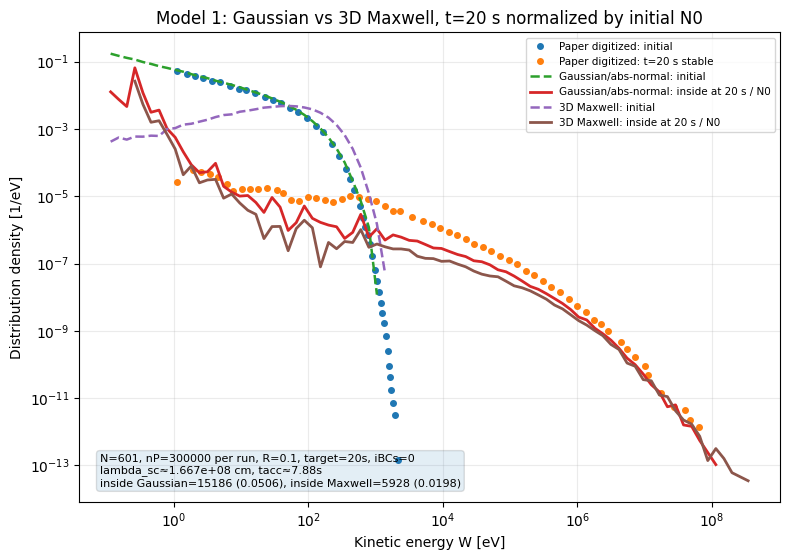

Saved plot to: D:\download\intern\fig1b_gaussian_vs_maxwell_N0norm.png


In [62]:
fig, ax = show_comparison_plot(result_gauss, result_maxwell, cfg)
plt.show()

# Optional: save the displayed figure.
fig.savefig(cfg.output, dpi=220)
print(f"Saved plot to: {Path(cfg.output).resolve()}")

## 13. Diagnostics

In [63]:
def print_diagnostics(result_gauss, result_maxwell, cfg):
    print("\nDiagnostics:")
    for name, result in [("Gaussian/abs-normal", result_gauss), ("3D Maxwell", result_maxwell)]:
        inside = result["inside_target"]
        Wt = result["W_inside_target_eV"][inside]

        print(f"  {name}:")
        print(f"    initial median [eV]: {np.median(result['W0_eV']):.6g}")
        print(
            f"    inside at target: {np.count_nonzero(inside)} / {cfg.n_particles} "
            f"(survival fraction = {np.mean(inside):.6g})"
        )
        if Wt.size:
            print(f"    target median [eV]: {np.median(Wt):.6g}")
            print(f"    target max [eV]: {np.max(Wt):.6g}")
        print(f"    mean kicks: {np.mean(result['kkicks']):.6g}")
        print(f"    mean head-on count: {np.mean(result['head_on']):.6g}")
        print(f"    mean following count: {np.mean(result['following']):.6g}")

print_diagnostics(result_gauss, result_maxwell, cfg)


Diagnostics:
  Gaussian/abs-normal:
    initial median [eV]: 22.6233
    inside at target: 15186 / 300000 (survival fraction = 0.05062)
    target median [eV]: 2438.05
    target max [eV]: 1.04394e+08
    mean kicks: 281.971
    mean head-on count: 46.991
    mean following count: 47.0055
  3D Maxwell:
    initial median [eV]: 118.59
    inside at target: 5928 / 300000 (survival fraction = 0.01976)
    target median [eV]: 94385.5
    target max [eV]: 3.30302e+08
    mean kicks: 294.062
    mean head-on count: 49.0162
    mean following count: 49.0121
